<a href="https://colab.research.google.com/github/PunamBhatia/LogicMojo-AI-ML-April26-Punam/blob/main/EDA%20Assignment%20-%20Logic%20Mojo/Credit_EDA_assignment_solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Data Loading

In [1]:
# Filtering out the warnings

import warnings

warnings.filterwarnings('ignore')

In [2]:
# Importing the required libraries

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# Read the csv file using 'read_csv'. Please write your dataset location here.

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
df = pd.read_csv('/content/drive/MyDrive/LogicMojo/EDA Assignment - Logic Mojo Sep/application_data.csv')
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
df.shape

(307511, 122)

In [6]:
df_prev = pd.read_csv('/content/drive/MyDrive/LogicMojo/EDA Assignment - Logic Mojo Sep/previous_application.csv')
df_prev.head()

,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,...,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,...,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,...,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,...,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,...,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,...,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
df_prev.shape

(1670214, 37)

# Data Cleaning

In [ ]:
#find if XNA is present replace with NaN

df = df.replace('XNA',np.nan)
df[df.isin(['XNA']).any(axis=1)]

In [8]:
### Find shape, Info & description of the data set
null_count = df.isnull().sum()
null_percentage = round((df.isnull().sum()/df.shape[0])*100, 2)
null_df = pd.DataFrame({'column_name' : df.columns,'null_count' : null_count,'null_percentage': null_percentage})
null_df.reset_index(drop = True, inplace = True)
null_df=null_df.sort_values(by = 'null_percentage', ascending = False)
display(null_df)
columns_to_delete= null_df[null_df['null_percentage']>47].column_name.to_list()
display(columns_to_delete)

len(columns_to_delete)

,column_name,null_count,null_percentage
48,COMMONAREA_AVG,214865,69.87
62,COMMONAREA_MODE,214865,69.87
76,COMMONAREA_MEDI,214865,69.87
84,NONLIVINGAPARTMENTS_MEDI,213514,69.43
70,NONLIVINGAPARTMENTS_MODE,213514,69.43
...,...,...,...
110,FLAG_DOCUMENT_16,0,0.00
109,FLAG_DOCUMENT_15,0,0.00
108,FLAG_DOCUMENT_14,0,0.00
114,FLAG_DOCUMENT_20,0,0.00


['COMMONAREA_AVG',
 'COMMONAREA_MODE',
 'COMMONAREA_MEDI',
 'NONLIVINGAPARTMENTS_MEDI',
 'NONLIVINGAPARTMENTS_MODE',
 'NONLIVINGAPARTMENTS_AVG',
 'FONDKAPREMONT_MODE',
 'LIVINGAPARTMENTS_AVG',
 'LIVINGAPARTMENTS_MEDI',
 'LIVINGAPARTMENTS_MODE',
 'FLOORSMIN_MODE',
 'FLOORSMIN_AVG',
 'FLOORSMIN_MEDI',
 'YEARS_BUILD_AVG',
 'YEARS_BUILD_MODE',
 'YEARS_BUILD_MEDI',
 'OWN_CAR_AGE',
 'LANDAREA_MEDI',
 'LANDAREA_AVG',
 'LANDAREA_MODE',
 'BASEMENTAREA_MODE',
 'BASEMENTAREA_MEDI',
 'BASEMENTAREA_AVG',
 'EXT_SOURCE_1',
 'NONLIVINGAREA_MODE',
 'NONLIVINGAREA_AVG',
 'NONLIVINGAREA_MEDI',
 'ELEVATORS_AVG',
 'ELEVATORS_MEDI',
 'ELEVATORS_MODE',
 'WALLSMATERIAL_MODE',
 'APARTMENTS_AVG',
 'APARTMENTS_MEDI',
 'APARTMENTS_MODE',
 'ENTRANCES_MODE',
 'ENTRANCES_MEDI',
 'ENTRANCES_AVG',
 'LIVINGAREA_AVG',
 'LIVINGAREA_MEDI',
 'LIVINGAREA_MODE',
 'HOUSETYPE_MODE',
 'FLOORSMAX_MODE',
 'FLOORSMAX_AVG',
 'FLOORSMAX_MEDI',
 'YEARS_BEGINEXPLUATATION_MODE',
 'YEARS_BEGINEXPLUATATION_MEDI',
 'YEARS_BEGINEXPLUATATIO

49

In [9]:
#drop columns with more than 47% null values
df.drop(columns=columns_to_delete, inplace=True)
df.shape

(307511, 73)

In [10]:
#lets check columns with less than 50% null and imput data if required
#cols_del=null_df[(null_df['null_percentage']>47) & (null_df['null_percentage']<=50)].column_name.to_list()
#df.drop(columns=cols_del, inplace=True)
null_df[(null_df['null_percentage']<=47) & (null_df['null_percentage'] > 0)].sort_values(by = 'null_percentage', ascending = False)

,column_name,null_count,null_percentage
28,OCCUPATION_TYPE,96391,31.35
43,EXT_SOURCE_3,60965,19.83
116,AMT_REQ_CREDIT_BUREAU_HOUR,41519,13.50
118,AMT_REQ_CREDIT_BUREAU_WEEK,41519,13.50
119,AMT_REQ_CREDIT_BUREAU_MON,41519,13.50
121,AMT_REQ_CREDIT_BUREAU_YEAR,41519,13.50
117,AMT_REQ_CREDIT_BUREAU_DAY,41519,13.50
120,AMT_REQ_CREDIT_BUREAU_QRT,41519,13.50
11,NAME_TYPE_SUITE,1292,0.42
94,DEF_60_CNT_SOCIAL_CIRCLE,1021,0.33


In [15]:
df.AMT_REQ_CREDIT_BUREAU_HOUR.value_counts() #frequent value is 0
display(df.AMT_REQ_CREDIT_BUREAU_DAY.value_counts()) #frequent value is 0
display(df.AMT_REQ_CREDIT_BUREAU_WEEK.value_counts()) #frequent value is 0
display(df.AMT_REQ_CREDIT_BUREAU_MON.value_counts()) #frequent value is 0
display(df.AMT_REQ_CREDIT_BUREAU_QRT.value_counts())#frequent value is 0
display(df.AMT_REQ_CREDIT_BUREAU_YEAR.value_counts()) #frequent value is 0

#imput mode for above columns
df.AMT_REQ_CREDIT_BUREAU_HOUR.fillna(df.AMT_REQ_CREDIT_BUREAU_HOUR.mode()[0], inplace=True)
df.AMT_REQ_CREDIT_BUREAU_DAY.fillna(df.AMT_REQ_CREDIT_BUREAU_DAY.mode()[0], inplace=True)
df.AMT_REQ_CREDIT_BUREAU_WEEK.fillna(df.AMT_REQ_CREDIT_BUREAU_WEEK.mode()[0], inplace=True)
df.AMT_REQ_CREDIT_BUREAU_MON.fillna(df.AMT_REQ_CREDIT_BUREAU_MON.mode()[0], inplace=True)
df.AMT_REQ_CREDIT_BUREAU_QRT.fillna(df.AMT_REQ_CREDIT_BUREAU_QRT.mode()[0], inplace=True)
df.AMT_REQ_CREDIT_BUREAU_YEAR.fillna(df.AMT_REQ_CREDIT_BUREAU_YEAR.mode()[0], inplace=True)



,count
AMT_REQ_CREDIT_BUREAU_DAY,
0.0,264503
1.0,1292
2.0,106
3.0,45
4.0,26
5.0,9
6.0,8
9.0,2
8.0,1


,count
AMT_REQ_CREDIT_BUREAU_WEEK,
0.0,257456
1.0,8208
2.0,199
3.0,58
4.0,34
6.0,20
5.0,10
8.0,5
7.0,2


,count
AMT_REQ_CREDIT_BUREAU_MON,
0.0,222233
1.0,33147
2.0,5386
3.0,1991
4.0,1076
5.0,602
6.0,343
7.0,298
9.0,206


,count
AMT_REQ_CREDIT_BUREAU_QRT,
0.0,215417
1.0,33862
2.0,14412
3.0,1717
4.0,476
5.0,64
6.0,28
8.0,7
7.0,7


,count
AMT_REQ_CREDIT_BUREAU_YEAR,
0.0,71801
1.0,63405
2.0,50192
3.0,33628
4.0,20714
5.0,12052
6.0,6967
7.0,3869
8.0,2127


In [21]:
df.isnull().sum().sort_values(ascending=False)
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 73 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   SK_ID_CURR                   307511 non-null  int64  
 1   TARGET                       307511 non-null  int64  
 2   NAME_CONTRACT_TYPE           307511 non-null  object 
 3   CODE_GENDER                  307511 non-null  object 
 4   FLAG_OWN_CAR                 307511 non-null  object 
 5   FLAG_OWN_REALTY              307511 non-null  object 
 6   CNT_CHILDREN                 307511 non-null  int64  
 7   AMT_INCOME_TOTAL             307511 non-null  float64
 8   AMT_CREDIT                   307511 non-null  float64
 9   AMT_ANNUITY                  307499 non-null  float64
 10  AMT_GOODS_PRICE              307233 non-null  float64
 11  NAME_TYPE_SUITE              306219 non-null  object 
 12  NAME_INCOME_TYPE             307511 non-null  object 
 13 

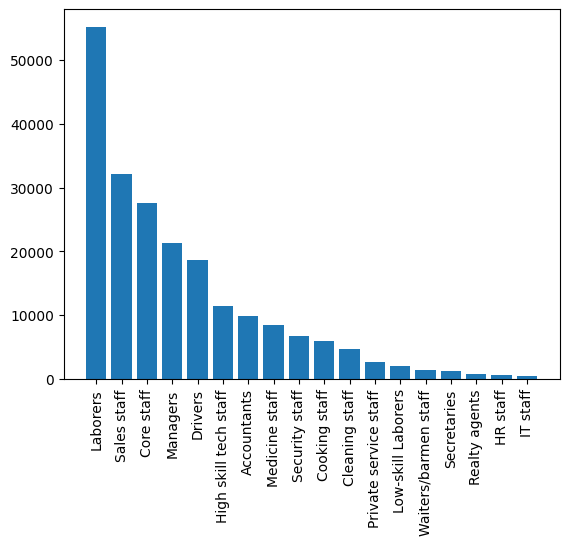

,count
OCCUPATION_TYPE,
Laborers,151577
Sales staff,32102
Core staff,27570
Managers,21371
Drivers,18603
High skill tech staff,11380
Accountants,9813
Medicine staff,8537
Security staff,6721


In [24]:
#imput null values in OccupationType with mode /most frequent value i.e. Laborers
df.OCCUPATION_TYPE.value_counts()
#lets plot frequency of occupation type
plt.bar(df.OCCUPATION_TYPE.value_counts().index, df.OCCUPATION_TYPE.value_counts().values)
plt.xticks(rotation=90)
plt.show()

df.OCCUPATION_TYPE.fillna('Laborers', inplace=True)
df.OCCUPATION_TYPE.value_counts()

In [25]:
# Impute Missing values in CODE_GENDER with mode
df.CODE_GENDER.value_counts()
df.CODE_GENDER.fillna('F', inplace=True)
df.CODE_GENDER.value_counts()

,count
CODE_GENDER,
F,202448
M,105059
XNA,4


In [28]:

df.EXT_SOURCE_3.value_counts()
df.EXT_SOURCE_3.fillna(df.EXT_SOURCE_3.median(), inplace=True)
df.EXT_SOURCE_3.value_counts()

,count
EXT_SOURCE_3,
0.535276,61751
0.746300,1460
0.713631,1315
0.694093,1276
0.670652,1191
...,...
0.028275,1
0.858178,1
0.849170,1


In [39]:
df.ORGANIZATION_TYPE.value_counts()
df.ORGANIZATION_TYPE.fillna('Business Entity Type 3', inplace=True)
df.ORGANIZATION_TYPE.value_counts()

,count
ORGANIZATION_TYPE,
Business Entity Type 3,123366
Self-employed,38412
Other,16683
Medicine,11193
Business Entity Type 2,10553
Government,10404
School,8893
Trade: type 7,7831
Kindergarten,6880


In [40]:
(df.isnull().mean()*100).sort_values(ascending=False)

,0
NAME_TYPE_SUITE,0.420148
OBS_30_CNT_SOCIAL_CIRCLE,0.332021
DEF_30_CNT_SOCIAL_CIRCLE,0.332021
OBS_60_CNT_SOCIAL_CIRCLE,0.332021
DEF_60_CNT_SOCIAL_CIRCLE,0.332021
...,...
AMT_REQ_CREDIT_BUREAU_DAY,0.000000
AMT_REQ_CREDIT_BUREAU_WEEK,0.000000
AMT_REQ_CREDIT_BUREAU_MON,0.000000
AMT_REQ_CREDIT_BUREAU_QRT,0.000000


In [44]:
#lets delete all columns starting with 'FLAG'
flag_columns=df.columns[df.columns.str.startswith('FLAG')].to_list()
display(flag_columns)

df.drop(columns=flag_columns, inplace=True)
df.shape

['FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'FLAG_MOBIL',
 'FLAG_EMP_PHONE',
 'FLAG_WORK_PHONE',
 'FLAG_CONT_MOBILE',
 'FLAG_PHONE',
 'FLAG_EMAIL',
 'FLAG_DOCUMENT_2',
 'FLAG_DOCUMENT_3',
 'FLAG_DOCUMENT_4',
 'FLAG_DOCUMENT_5',
 'FLAG_DOCUMENT_6',
 'FLAG_DOCUMENT_7',
 'FLAG_DOCUMENT_8',
 'FLAG_DOCUMENT_9',
 'FLAG_DOCUMENT_10',
 'FLAG_DOCUMENT_11',
 'FLAG_DOCUMENT_12',
 'FLAG_DOCUMENT_13',
 'FLAG_DOCUMENT_14',
 'FLAG_DOCUMENT_15',
 'FLAG_DOCUMENT_16',
 'FLAG_DOCUMENT_17',
 'FLAG_DOCUMENT_18',
 'FLAG_DOCUMENT_19',
 'FLAG_DOCUMENT_20',
 'FLAG_DOCUMENT_21']

(307511, 45)

In [53]:
display(df.info())
display(df['AMT_INCOME_TOTAL'].isnull().sum())
display(df['AMT_CREDIT'].isnull().sum())
display(df['AMT_ANNUITY'].isnull().sum()) #12 null values
display(df['AMT_GOODS_PRICE'].isnull().sum()) #278 null values

#Impute Missing values for AMT_ANNUITY & AMT_GOODS_PRICE
df.AMT_ANNUITY.fillna(df.AMT_ANNUITY.median(), inplace=True)
df.AMT_GOODS_PRICE.fillna(df.AMT_GOODS_PRICE.median(), inplace=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 45 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   SK_ID_CURR                   307511 non-null  int64  
 1   TARGET                       307511 non-null  int64  
 2   NAME_CONTRACT_TYPE           307511 non-null  object 
 3   CODE_GENDER                  307507 non-null  object 
 4   CNT_CHILDREN                 307511 non-null  int64  
 5   AMT_INCOME_TOTAL             307511 non-null  float64
 6   AMT_CREDIT                   307511 non-null  float64
 7   AMT_ANNUITY                  307499 non-null  float64
 8   AMT_GOODS_PRICE              307233 non-null  float64
 9   NAME_TYPE_SUITE              306219 non-null  object 
 10  NAME_INCOME_TYPE             307511 non-null  object 
 11  NAME_EDUCATION_TYPE          307511 non-null  object 
 12  NAME_FAMILY_STATUS           307511 non-null  object 
 13 

None

np.int64(0)

np.int64(0)

np.int64(12)

np.int64(278)

In [55]:
# now check for days columns
df[df.columns[df.columns.str.startswith('DAYS')]]
#convert to absolute values
df[df.columns[df.columns.str.startswith('DAYS')]] = df[df.columns[df.columns.str.startswith('DAYS')]].abs()
df[df.columns[df.columns.str.startswith('DAYS')]]


,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,DAYS_LAST_PHONE_CHANGE
0,9461,637,3648.0,2120,1134.0
1,16765,1188,1186.0,291,828.0
2,19046,225,4260.0,2531,815.0
3,19005,3039,9833.0,2437,617.0
4,19932,3038,4311.0,3458,1106.0
...,...,...,...,...,...
307506,9327,236,8456.0,1982,273.0
307507,20775,365243,4388.0,4090,0.0
307508,14966,7921,6737.0,5150,1909.0
307509,11961,4786,2562.0,931,322.0


In [56]:
#lets convert DAYS_EMPLOYED to YEARS_EMPLOYED and DAYS_BIRTH to CLIENT_AGE
df['YEARS_EMPLOYED'] = df['DAYS_EMPLOYED']/365
df['CLIENT_AGE'] = df['DAYS_BIRTH']/365
df.drop(columns=['DAYS_EMPLOYED', 'DAYS_BIRTH'], inplace=True)


# Univariate Analysis

In [ ]:
### build understanding of the fields and use business sense to analyse which fileds are just noise 9 additional/ extra) and might not help in the analysis
### remove them if you feel it wont be useful

In [ ]:
### list down business questions which will help you analyse this data



In [ ]:
### Check the data for nulls and remove all columns with > 30/40% nulls

df.isnull().sum()/len(df) * 100

In [ ]:
#### IF data is missing for < 30% of the nulls values ->
### 1. Figure if that colums in necessary for analysis - Remove
### 2. See if imputation would make sense - > Replace the nulls using mean. median. mode .    [Try to impute using intraplation] [Advanced]

#### If a columns more 7-10% nulls, rather not impute -> manufacturing of data

### Replace?

### create box plots -> Outliers -> too many outliers -> Replace with median

df.loc[df.AMT_ANNUITY.isnull(), 'AMT_ANNUITY'] = median ()

In [ ]:
### study the values of columns for nulls - >
### there are few columns with values like NAN, NaN, XNA, XA -> Junk values ( filter these rows out if the junk values are more > 30% ) If it is less, see if you can impute

In [ ]:
## Check for gender, occuption type for junks

In [ ]:
#### outlier analysis


##Study if variables have outliers -> Box plot, IQR ( In for loop for multiple variables)

### study why there are outliers, does it makes sense or not
### For variables which do not make sense to have outliers, remove outliers using IQR - 90/10- or 95/5

In [ ]:
#### Univariate Analysis

### Pick one variable and understand the counts/ group by sums/ plot bar charts/ distributions  - Employee distrbution -> Salaried class are the most applicants in a loan setting

### Salaried class Employees are the ones with highest loan rejections


var_name. value_counts().plot.bar()

In [ ]:
### categorical variables

###Frequency charts - BoX


In [ ]:
### Some variables like Income, Credit History etc would be better to be analysed using bins - create 10/15 bins for this
l = ['2-100','101-200']
bins = [0,100,200]
pd.cut(df.var_name, bins, labels = l)

In [ ]:
### Class Imbalance

###target Variable - Count- > What is the ratio of this

In [ ]:
#### multivariate Analysis

### target with AMT_credit , Employee type, occupation type -> Bar plot hue - Stacked bar plot, Scatter Plots
### correlation multiple variables


plot(df, col = 'Income Type', hue = 'code_gender')



### Count the applications based on organization type

###  Distribution of goods price with contract type


# heatmap - corr()

### Which the 10 most correlated variables

## Scatter plots with annuity and credit amount

### use subplots wherever necessary

## study Education type, occupation type, Assets

### Create more columns -> Combining assets


### family Status vs credit amount

In [ ]:
### merge the previous application data to the previous one for more insights

In [ ]:
### previous follow same steps -> Clean data, remove null columns, remove uncessary junk columns, fill na by logic if required, outlier analysis


In [ ]:
## Purpose of previous laon , contract status with previopsu loan

In [ ]:
### Summary - Recommendations, Trends, Insights imp for the business
